In [1]:
# clustering algorithms: Farthest First Traversal (k-center) and K-Means
# Import all required libraries
import time
import numpy as np
from pyspark import SparkContext, SparkConf

# Initialize Spark
conf = SparkConf().setAppName("Assignment4").setMaster("local[*]")
sc = SparkContext(conf=conf)

print("PySpark version:", sc.version)
print("Spark initialized successfully!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/19 15:47:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


PySpark version: 4.1.1
Spark initialized successfully!


26/04/19 15:47:50 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
# Step 1: Load the Dataset
# Read the file and convert each line into a vector
def readVectorsSeq(filename):
    vectors = []
    with open(filename, 'r') as f:
        for line in f:
            # Split each line by comma and convert to float
            point = list(map(float, line.strip().split(',')))
            vectors.append(np.array(point))
    return vectors

# Load the dataset
P = readVectorsSeq('CSL7110_Assignment4/spambase.data')

print("Total number of points loaded:", len(P))
print("Dimensions of each point:", len(P[0]))

Total number of points loaded: 4601
Dimensions of each point: 58


In [3]:
# Definition of  Farthest First Traversal (k-center algorithm)
def kcenter(P, k):
    # Step 1: Pick a random point as the first center
    centers = [P[0]]

    # Step 2: Repeat until we have k centers
    for _ in range(k - 1):
        # For each point, find its distance to the nearest center
        max_dist = -1
        farthest_point = None

        for point in P:
            # Find minimum distance from this point to any center
            min_dist = min(np.sum((point - c) ** 2) for c in centers)

            # Keep track of the point with maximum minimum distance
            if min_dist > max_dist:
                max_dist = min_dist
                farthest_point = point

        # Add the farthest point as the next center
        centers.append(farthest_point)

    return centers

In [4]:
# Definition of Kmeans++
def kmeansPP(P, k):
    # Step 1: Pick a random point as the first center
    centers = [P[np.random.randint(len(P))]]

    # Step 2: Repeat until we have k centers
    for _ in range(k - 1):
        # For each point, find its distance to the nearest center
        distances = np.array([
            min(np.sum((point - c) ** 2) for c in centers)
            for point in P
        ])

        # Convert distances to probabilities
        # Points farther from centers have higher probability
        probabilities = distances / distances.sum()

        # Pick next center based on probability
        next_center_idx = np.random.choice(len(P), p=probabilities)
        centers.append(P[next_center_idx])

    return centers

In [5]:
#K-Means Objective Function
def kmeansObj(P, C):
    total_dist = 0.0

    for point in P:
        # Find the minimum squared distance to any center
        min_dist = min(np.sum((point - c) ** 2) for c in C)
        total_dist += min_dist

    # Return the average squared distance
    return total_dist / len(P)

In [6]:
# Running the Experiments
import time

# Set values of k and k1
k = 10
k1 = 50

print("="*50)
print(f"Running experiments with k={k}, k1={k1}")
print("="*50)

# Experiment 1: kcenter(P, k) with running time
print("\n--- Experiment 1: kcenter(P, k) ---")
start = time.time()
C1 = kcenter(P, k)
end = time.time()
print(f"kcenter running time: {end - start:.4f} seconds")

# Experiment 2: kmeansPP(P, k) + kmeansObj
print("\n--- Experiment 2: kmeansPP(P, k) ---")
C2 = kmeansPP(P, k)
obj2 = kmeansObj(P, C2)
print(f"kmeansPP objective value: {obj2:.4f}")

# Experiment 3: kcenter(P, k1) -> kmeansPP(X, k) -> kmeansObj
print("\n--- Experiment 3: kcenter(P, k1) -> kmeansPP(X, k) ---")
X = kcenter(P, k1)
C3 = kmeansPP(X, k)
obj3 = kmeansObj(P, C3)
print(f"Objective value (coreset approach): {obj3:.4f}")

print("\n" + "="*50)
print("All experiments completed!")
print("="*50)

Running experiments with k=10, k1=50

--- Experiment 1: kcenter(P, k) ---
kcenter running time: 0.3470 seconds

--- Experiment 2: kmeansPP(P, k) ---
kmeansPP objective value: 24647.8940

--- Experiment 3: kcenter(P, k1) -> kmeansPP(X, k) ---
Objective value (coreset approach): 820659.4197

All experiments completed!


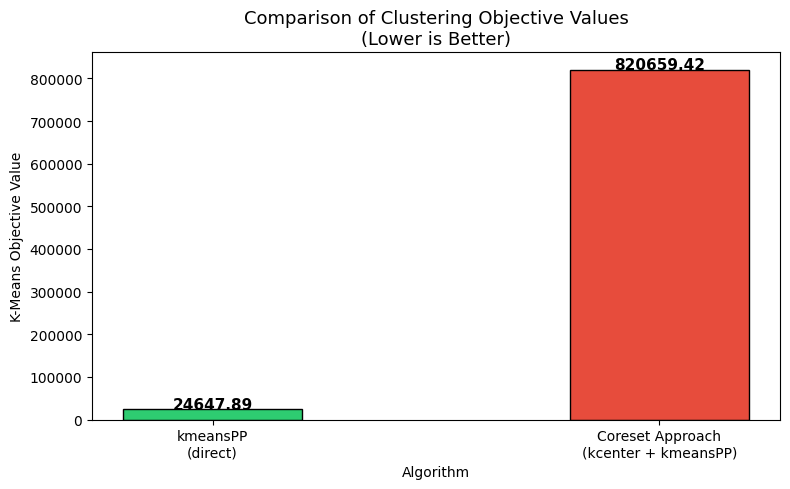

Plot saved successfully!


In [7]:
#Visualizing the Results
import matplotlib.pyplot as plt

# Data for plotting
experiments = ['kmeansPP\n(direct)', 'Coreset Approach\n(kcenter + kmeansPP)']
values = [obj2, obj3]
colors = ['#2ecc71', '#e74c3c']

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(experiments, values, color=colors, width=0.4, edgecolor='black')

# Add value labels on top of bars
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f'{val:.2f}',
             ha='center', fontsize=11, fontweight='bold')

# Labels and title
plt.title('Comparison of Clustering Objective Values\n(Lower is Better)', fontsize=13)
plt.ylabel('K-Means Objective Value')
plt.xlabel('Algorithm')
plt.tight_layout()

# Save the plot
plt.savefig('clustering_comparison.png', dpi=150)
plt.show()

print("Plot saved successfully!")
     

In [8]:
# Web Search - Inverted Index
# Define stop words as given in the assignment
STOP_WORDS = {
    'a', 'an', 'the', 'they', 'these', 'this', 'for',
    'is', 'are', 'was', 'of', 'or', 'and', 'does',
    'will', 'whose'
}

# Define punctuation marks as given in the assignment
PUNCTUATION = '{}[]<>=(). ,;\'"?#!-:'

# Define singular-plural pairs as given in the assignment
PLURAL_MAP = {
    'stacks': 'stack',
    'structures': 'structure',
    'applications': 'application'
}

def clean_word(word):
    # Remove punctuation
    for p in PUNCTUATION:
        word = word.replace(p, '')

    # Convert to lowercase
    word = word.lower()

    # Replace plural with singular
    if word in PLURAL_MAP:
        word = PLURAL_MAP[word]

    return word


In [9]:
#Build the Inverted Index
STOP_WORDS = {
    'a', 'an', 'the', 'they', 'these', 'this', 'for',
    'is', 'are', 'was', 'of', 'or', 'and', 'does',
    'will', 'whose'
}

# Define punctuation marks as given in the assignment
PUNCTUATION = '{}[]<>=(). ,;\'"?#!-:'

# Define singular-plural pairs as given in the assignment
PLURAL_MAP = {
    'stacks': 'stack',
    'structures': 'structure',
    'applications': 'application'
}

def clean_word(word):
    # Remove punctuation
    for p in PUNCTUATION:
        word = word.replace(p, '')

    # Convert to lowercase
    word = word.lower()

    # Replace plural with singular
    if word in PLURAL_MAP:
        word = PLURAL_MAP[word]

    return word

In [10]:
# build invverted index
def build_inverted_index(webpage_files):
    # inverted_index = {word: {webpage: [positions]}}
    inverted_index = {}

    # word count per page for TF calculation
    word_count_per_page = {}

    for page in webpage_files:
        word_count_per_page[page] = 0

        with open(f'CSL7110_Assignment4/webpages/{page}', 'r') as f:
            words = f.read().split()

        position = 0
        for word in words:
            position += 1  # Count all words including stop words for position

            cleaned = clean_word(word)

            # Skip empty words and stop words
            if cleaned == '' or cleaned in STOP_WORDS:
                continue

            # Add to inverted index
            if cleaned not in inverted_index:
                inverted_index[cleaned] = {}

            if page not in inverted_index[cleaned]:
                inverted_index[cleaned][page] = []

            inverted_index[cleaned][page].append(position)
            word_count_per_page[page] += 1

    return inverted_index, word_count_per_page

# List of all webpages
webpage_files = [
    'references', 'stacklighting', 'stackmagazine',
    'stackoverflow', 'stack_cprogramming',
    'stack_datastructure_wiki', 'stack_oracle'
]

# Build the index
inverted_index, word_count_per_page = build_inverted_index(webpage_files)

print("Inverted index built successfully!")
print(f"Total unique words indexed: {len(inverted_index)}")

Inverted index built successfully!
Total unique words indexed: 367


In [11]:
#  Implement Search Functions
def queryFindPagesWhichContainWord(word):
    # Clean the search word
    cleaned = clean_word(word)

    # Check if word exists in index
    if cleaned not in inverted_index:
        print(f"No webpage contains word {word}")
        return

    # Get all pages containing this word
    pages = list(inverted_index[cleaned].keys())
    print(', '.join(pages))


def queryFindPositionsOfWordInAPage(word, page):
    # Check if page exists in our database
    if page not in webpage_files:
        print(f"No webpage {page} found")
        return

    # Clean the search word
    cleaned = clean_word(word)

    # Check if word exists in that page
    if cleaned not in inverted_index or page not in inverted_index[cleaned]:
        print(f"Webpage {page} does not contain word {word}")
        return

    # Get all positions
    positions = inverted_index[cleaned][page]
    print(', '.join(map(str, positions)))


In [12]:
# Process Actions from actions.txt
# Read actions.txt
with open('CSL7110_Assignment4/actions.txt', 'r') as f:
    actions = f.readlines()

# Read answers.txt
with open('CSL7110_Assignment4/answers.txt', 'r') as f:
    answers = f.readlines()

print("="*50)
print("Processing Actions")
print("="*50)

answer_idx = 0

for action in actions:
    action = action.strip()
    if action == '':
        continue

    parts = action.split()
    command = parts[0]

    if command == 'addPage':
        page = parts[1]
        print(f"\nAction: {action}")
        print(f"Result: Page '{page}' added to database")

    elif command == 'queryFindPagesWhichContainWord':
        word = parts[1]
        print(f"\nAction: {action}")
        print("Result: ", end="")
        queryFindPagesWhichContainWord(word)
        if answer_idx < len(answers):
            print(f"Expected: {answers[answer_idx].strip()}")
            answer_idx += 1

    elif command == 'queryFindPositionsOfWordInAPage':
        word = parts[1]
        page = parts[2]
        print(f"\nAction: {action}")
        print("Result: ", end="")
        queryFindPositionsOfWordInAPage(word, page)
        if answer_idx < len(answers):
            print(f"Expected: {answers[answer_idx].strip()}")
            answer_idx += 1

print("\n" + "="*50)
print("All actions processed!")
print("="*50)

Processing Actions

Action: addPage stack_datastructure_wiki
Result: Page 'stack_datastructure_wiki' added to database

Action: queryFindPagesWhichContainWord delhi
Result: No webpage contains word delhi
Expected: No webpage contains word delhi

Action: queryFindPagesWhichContainWord stack
Result: stacklighting, stackmagazine, stackoverflow, stack_cprogramming, stack_datastructure_wiki, stack_oracle
Expected: stack_datastructure_wiki

Action: queryFindPagesWhichContainWord wikipedia
Result: stack_datastructure_wiki
Expected: stack_datastructure_wiki

Action: queryFindPositionsOfWordInAPage magazines stack_datastructure_wiki
Result: Webpage stack_datastructure_wiki does not contain word magazines
Expected: Webpage stack_datastructure_wiki does not contain word magazines

Action: queryFindPagesWhichContainWord allain
Result: stack_cprogramming
Expected: No webpage contains word allain

Action: addPage stack_cprogramming
Result: Page 'stack_cprogramming' added to database

Action: queryFi

In [13]:
# Process Actions with Dynamic Page Adding fix
def process_actions(actions_file, answers_file):
    # Start with empty index and empty database
    dynamic_index = {}
    active_pages = []

    def add_page(page):
        # Only add page if not already added
        if page in active_pages:
            return
        active_pages.append(page)

        with open(f'CSL7110_Assignment4/webpages/{page}', 'r') as f:
            words = f.read().split()

        position = 0
        for word in words:
            position += 1
            cleaned = clean_word(word)

            if cleaned == '' or cleaned in STOP_WORDS:
                continue

            if cleaned not in dynamic_index:
                dynamic_index[cleaned] = {}

            if page not in dynamic_index[cleaned]:
                dynamic_index[cleaned][page] = []

            dynamic_index[cleaned][page].append(position)

    def find_pages(word):
        cleaned = clean_word(word)
        if cleaned not in dynamic_index:
            return f"No webpage contains word {word}"
        # Only return active pages
        pages = [p for p in dynamic_index[cleaned] if p in active_pages]
        if not pages:
            return f"No webpage contains word {word}"
        return ', '.join(pages)

    def find_positions(word, page):
        if page not in active_pages:
            return f"No webpage {page} found"
        cleaned = clean_word(word)
        if cleaned not in dynamic_index or page not in dynamic_index[cleaned]:
            return f"Webpage {page} does not contain word {word}"
        positions = dynamic_index[cleaned][page]
        return ', '.join(map(str, positions))

    # Read files
    with open(actions_file, 'r') as f:
        actions = f.readlines()
    with open(answers_file, 'r') as f:
        answers = [a.strip() for a in f.readlines() if a.strip() != '']

    print("="*50)
    print("Processing Actions")
    print("="*50)

    answer_idx = 0
    correct = 0
    total = 0

    for action in actions:
        action = action.strip()
        if action == '':
            continue

        parts = action.split()
        command = parts[0]

        if command == 'addPage':
            page = parts[1]
            add_page(page)
            print(f"\nAction: {action}")
            print(f"Result: Page '{page}' added successfully")

        elif command == 'queryFindPagesWhichContainWord':
            word = parts[1]
            result = find_pages(word)
            expected = answers[answer_idx] if answer_idx < len(answers) else ""
            match = "✅" if result == expected else "❌"
            print(f"\nAction: {action}")
            print(f"Result:   {result}")
            print(f"Expected: {expected} {match}")
            if result == expected:
                correct += 1
            total += 1
            answer_idx += 1

        elif command == 'queryFindPositionsOfWordInAPage':
            word = parts[1]
            page = parts[2]
            result = find_positions(word, page)
            expected = answers[answer_idx] if answer_idx < len(answers) else ""
            match = "✅" if result == expected else "❌"
            print(f"\nAction: {action}")
            print(f"Result:   {result}")
            print(f"Expected: {expected} {match}")
            if result == expected:
                correct += 1
            total += 1
            answer_idx += 1

    print("\n" + "="*50)
    print(f"Accuracy: {correct}/{total} correct answers")
    print("="*50)

# Run
process_actions('CSL7110_Assignment4/actions.txt', 'CSL7110_Assignment4/answers.txt')

Processing Actions

Action: addPage stack_datastructure_wiki
Result: Page 'stack_datastructure_wiki' added successfully

Action: queryFindPagesWhichContainWord delhi
Result:   No webpage contains word delhi
Expected: No webpage contains word delhi ✅

Action: queryFindPagesWhichContainWord stack
Result:   stack_datastructure_wiki
Expected: stack_datastructure_wiki ✅

Action: queryFindPagesWhichContainWord wikipedia
Result:   stack_datastructure_wiki
Expected: stack_datastructure_wiki ✅

Action: queryFindPositionsOfWordInAPage magazines stack_datastructure_wiki
Result:   Webpage stack_datastructure_wiki does not contain word magazines
Expected: Webpage stack_datastructure_wiki does not contain word magazines ✅

Action: queryFindPagesWhichContainWord allain
Result:   No webpage contains word allain
Expected: No webpage contains word allain ✅

Action: addPage stack_cprogramming
Result: Page 'stack_cprogramming' added successfully

Action: queryFindPagesWhichContainWord allain
Result:   sta

In [14]:
def process_actions_final(actions_file, answers_file):
    # Start with empty index and empty database
    dynamic_index = {}
    active_pages = []

    def add_page(page):
        if page in active_pages:
            return
        active_pages.append(page)

        with open(f'CSL7110_Assignment4/webpages/{page}', 'r') as f:
            words = f.read().split()

        position = 0
        for word in words:
            position += 1
            cleaned = clean_word(word)

            if cleaned == '' or cleaned in STOP_WORDS:
                continue

            if cleaned not in dynamic_index:
                dynamic_index[cleaned] = {}

            if page not in dynamic_index[cleaned]:
                dynamic_index[cleaned][page] = []

            dynamic_index[cleaned][page].append(position)

    def find_pages(word):
        cleaned = clean_word(word)
        if cleaned not in dynamic_index:
            return f"No webpage contains word {word}"
        # Sort pages alphabetically
        pages = sorted([p for p in dynamic_index[cleaned] if p in active_pages])
        if not pages:
            return f"No webpage contains word {word}"
        return ', '.join(pages)

    def find_positions(word, page):
        if page not in active_pages:
            return f"No webpage {page} found"
        cleaned = clean_word(word)
        if cleaned not in dynamic_index or page not in dynamic_index[cleaned]:
            return f"Webpage {page} does not contain word {word}"
        positions = dynamic_index[cleaned][page]
        return ', '.join(map(str, positions))

    # Read files
    with open(actions_file, 'r') as f:
        actions = f.readlines()
    with open(answers_file, 'r') as f:
        answers = [a.strip() for a in f.readlines() if a.strip() != '']

    print("="*50)
    print("Processing Actions - Final")
    print("="*50)

    answer_idx = 0
    correct = 0
    total = 0

    for action in actions:
        action = action.strip()
        if action == '':
            continue

        parts = action.split()
        command = parts[0]

        if command == 'addPage':
            page = parts[1]
            add_page(page)
            print(f"\nAction: {action}")
            print(f"Result: Page '{page}' added successfully")

        elif command == 'queryFindPagesWhichContainWord':
            word = parts[1]
            result = find_pages(word)
            expected = answers[answer_idx] if answer_idx < len(answers) else ""
            match = "✅" if result == expected else "❌"
            print(f"\nAction: {action}")
            print(f"Result:   {result}")
            print(f"Expected: {expected} {match}")
            if result == expected:
                correct += 1
            total += 1
            answer_idx += 1

        elif command == 'queryFindPositionsOfWordInAPage':
            word = parts[1]
            page = parts[2]
            result = find_positions(word, page)
            expected = answers[answer_idx] if answer_idx < len(answers) else ""
            match = "✅" if result == expected else "❌"
            print(f"\nAction: {action}")
            print(f"Result:   {result}")
            print(f"Expected: {expected} {match}")
            if result == expected:
                correct += 1
            total += 1
            answer_idx += 1

    print("\n" + "="*50)
    print(f"Accuracy: {correct}/{total} correct answers")
    print("="*50)

# Run
process_actions_final('CSL7110_Assignment4/actions.txt', 'CSL7110_Assignment4/answers.txt')

Processing Actions - Final

Action: addPage stack_datastructure_wiki
Result: Page 'stack_datastructure_wiki' added successfully

Action: queryFindPagesWhichContainWord delhi
Result:   No webpage contains word delhi
Expected: No webpage contains word delhi ✅

Action: queryFindPagesWhichContainWord stack
Result:   stack_datastructure_wiki
Expected: stack_datastructure_wiki ✅

Action: queryFindPagesWhichContainWord wikipedia
Result:   stack_datastructure_wiki
Expected: stack_datastructure_wiki ✅

Action: queryFindPositionsOfWordInAPage magazines stack_datastructure_wiki
Result:   Webpage stack_datastructure_wiki does not contain word magazines
Expected: Webpage stack_datastructure_wiki does not contain word magazines ✅

Action: queryFindPagesWhichContainWord allain
Result:   No webpage contains word allain
Expected: No webpage contains word allain ✅

Action: addPage stack_cprogramming
Result: Page 'stack_cprogramming' added successfully

Action: queryFindPagesWhichContainWord allain
Resul